In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from pyLDAvis import gensim_models as gensimvis
from gensim.models import CoherenceModel
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary
from wordsegment import load, segment
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pyLDAvis import save_html
from pprint import pprint
from nltk import pos_tag
import pandas as pd
import pyLDAvis
import nltk
import re
import os

In [2]:
load()  
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/edoardoconti/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/edoardoconti/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/edoardoconti/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/edoardoconti/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# <b> 0. Text Pre-processing

In [3]:
def wn_tag(ptag):
    """
    Convert NLTK POS tags to WordNet POS tags.
    """
    if ptag.startswith('J'): return wordnet.ADJ
    if ptag.startswith('V'): return wordnet.VERB
    if ptag.startswith('N'): return wordnet.NOUN
    if ptag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

In [4]:
def segment_tokenize_text(text):
    """
    Segments the input tokens into words using wordsegment, then returns the list of tokens.
    """
    stops = stopwords.words('english')
            
    tokens = word_tokenize(text)

    token_list = []
    for token in tokens:
        if token.isalpha() and token not in stops:
            seg = segment(token)
            token_list.extend(seg)

    return token_list

In [5]:
def preprocess_text(text):
    """
    Preprocess the input text by removing unwanted characters and normalizing it.
    """
    pattern = r'[^A-Za-z\s]'
    text = re.sub(pattern, '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    token_list = segment_tokenize_text(text)

    return token_list

In [6]:
def load_file_content(file_path):
    """
    Loads the content of a file.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        corpus = f.read()
    
    return corpus

In [7]:
def get_status_date(file_dir):
    """
    Extracts the status and date from the file name.
    """
    pattern = re.compile(
    r'_H.R.\d{1,4}_(?P<status>.+?) \((?P<date>\d{2}_\d{2}_\d{4})\)\.txt$'
    )

    m = pattern.search(file_dir)
    if m:
        return m.group('status').strip(), m.group('date').strip()

In [8]:
def lemmatize(pos_tags):
    """
    Lemmatize the input tokens using WordNetLemmatizer."""
    stops = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    lemmas = []
    for token, ptag in pos_tags:
        wn_ptag = wn_tag(ptag)
        lemmas.append(lemmatizer.lemmatize(token, wn_ptag))

    tokens = [l for l in lemmas if l not in stops and len(l) > 2]
    return tokens

In [9]:
folder_path = 'summaries118'
data = []

In [10]:
for idx, file_dir in enumerate(os.scandir(folder_path)):
    file_path = os.path.join(folder_path, file_dir.name)
    
    status,date = get_status_date(file_dir.name)
    corpus = load_file_content(file_path)

    tokens = preprocess_text(corpus)

    n_rec = {
        'id': idx,
        'content':corpus,
        'tokens': tokens,
        'file_name': file_dir,
        'status': status,
        'date': date.replace('_', '-')
    }

    data.append(n_rec)

In [11]:
df = pd.DataFrame(data)

In [12]:
df['pos_tags'] = df['tokens'].map(lambda x: pos_tag(x))

In [13]:
df['lemmatized_tokens'] = df['pos_tags'].map(lambda x: lemmatize(x))

# <b>1. Topic Modeling

## ***A - LDA***

In [14]:
# 0.25 --> 1200, 0.50 --> 1214, 0.75 --> 1214, 0.90 --> 1215
tokens = df['lemmatized_tokens'].tolist()
dictionary = Dictionary(tokens)
dictionary.filter_extremes(no_below=30, no_above=0.5)
print(f"Dictionary size: {len(dictionary)}")

Dictionary size: 1214


In [15]:
corpus = [dictionary.doc2bow(token) for token in tokens]
for i in range(5):
    print(f'Doc-{i}',corpus[i])

Doc-0 [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 2), (7, 1), (8, 6), (9, 1), (10, 2), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 3), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 2), (27, 1), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 5), (36, 1), (37, 1), (38, 1), (39, 2), (40, 2), (41, 2), (42, 2), (43, 1), (44, 1), (45, 2), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 2), (54, 5), (55, 2)]
Doc-1 [(0, 1), (1, 1), (7, 1), (12, 1), (13, 1), (32, 1), (43, 1), (44, 1), (46, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 4), (61, 3), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 2), (68, 1), (69, 4), (70, 2), (71, 1), (72, 1), (73, 2), (74, 2), (75, 3), (76, 3), (77, 2), (78, 3), (79, 1), (80, 1), (81, 2), (82, 1), (83, 2), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 2), (92, 1), (93, 1), (94, 1), (95, 1), (96, 2), (97, 4), (98, 1), (99, 3), (100, 1),

In [16]:
temp = dictionary[0]

id2w = dictionary.id2token

In [17]:
model = LdaModel(
    corpus=corpus,
    id2word=id2w,
    num_topics=23,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

In [18]:
topics = model.print_topics(num_words=5)
pprint(topics)

[(3,
  '0.066*"sec" + 0.063*"section" + 0.027*"dod" + 0.019*"require" + '
  '0.015*"department"'),
 (13,
  '0.097*"loan" + 0.044*"federal" + 0.038*"fee" + 0.038*"student" + '
  '0.031*"payment"'),
 (21,
  '0.041*"appropriation" + 0.037*"service" + 0.035*"office" + 0.035*"provide" '
  '+ 0.029*"department"'),
 (14,
  '0.059*"fund" + 0.053*"section" + 0.040*"provide" + 0.040*"sec" + '
  '0.028*"program"'),
 (20,
  '0.057*"election" + 0.038*"state" + 0.035*"federal" + 0.032*"vote" + '
  '0.021*"voter"'),
 (16,
  '0.109*"member" + 0.057*"force" + 0.035*"arm" + 0.028*"military" + '
  '0.027*"cancer"'),
 (8,
  '0.072*"drug" + 0.038*"food" + 0.034*"product" + 0.026*"must" + '
  '0.025*"requirement"'),
 (18,
  '0.028*"security" + 0.027*"national" + 0.026*"congress" + 0.026*"foreign" + '
  '0.019*"require"'),
 (22,
  '0.038*"energy" + 0.023*"gas" + 0.023*"water" + 0.021*"must" + '
  '0.020*"environmental"'),
 (17,
  '0.055*"individual" + 0.036*"state" + 0.022*"certain" + 0.018*"united" + '
  '0

In [19]:
coherence_model = CoherenceModel(
    model=model,
    texts=tokens,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

Coherence Score: 0.4533


In [20]:
pyLDAvis.enable_notebook()
vis_data = gensimvis.prepare(model, corpus, dictionary)

In [21]:
pyLDAvis.save_html(vis_data, 'pyLDA_graph.html')

In [21]:
pyLDAvis.display(vis_data)

In [ ]:
topic_nums = [i for i in range(5, 41)]
for num_t in topic_nums:
    model = LdaModel(
        corpus=corpus,
        id2word=id2w,
        num_topics=num_t,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True,
    )
    cm = CoherenceModel(
        model=model,
        texts=tokens,
        dictionary=dictionary,
        coherence='c_v'
    )
    cs = cm.get_coherence()
    print(f"Num Topics: {num_t}, Coherence Score: {cs:.4f}")

In [28]:
doc_topics = [model.get_document_topics(bow) for bow in corpus]

In [ ]:
doc_topics

In [35]:
dominant_topics = [
    max(doc_topics, key=lambda x: x[1])[0]  
    if doc_topics else None                
    for doc_topics in doc_topics
]

In [37]:
dominant = [
    max(doc_topics, key=lambda x: x[1]) if doc_topics else (None, 0.0)
    for doc_topics in doc_topics
]

In [39]:
df['topic']=[d[0] for d in dominant]
df['topic_prob']=[d[1] for d in dominant]

In [40]:
df.to_csv('dataset_LDA.csv',index=False)

In [ ]:
### END OF CODE FOR SECTION 1 ###

# <b> 2. Sematic Similarity

In [3]:
topic_df = pd.read_csv('dataset_LDA.csv')

In [69]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px
import umap.umap_ as umap
import numpy as np
import itertools
import warnings
import hdbscan

warnings.filterwarnings('ignore')

## ***A - TF_IDF***

In [6]:
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    lowercase=False,
    token_pattern=None,
)

In [7]:
tf_idf_M = vectorizer.fit_transform(topic_df['lemmatized_tokens'].tolist())
feature_names = vectorizer.get_feature_names_out()

In [8]:
sim = cosine_similarity(tf_idf_M)
topic_df['cos_sim'] = sim.tolist()

In [10]:
n_neighbors = [5,10,15,50,75,100,150]
distance = [0.05,0.1,0.15,0.25,0.5,0.9]
set_op_mix_ratio = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]

param_grid = list(itertools.product(n_neighbors,distance,set_op_mix_ratio))

In [11]:
dist = 1-sim
dist = np.clip(dist,0,1)
X_original = tf_idf_M.toarray()
topic_labels = topic_df['topic'].to_numpy()
hdb_cluster = hdbscan.HDBSCAN(min_cluster_size=5)

In [12]:
param_eval = {}

for idx,(n_ns,d,mix_r) in enumerate(param_grid):

    if idx % 10 == 0:
        print(f"Iteration: {idx}")

    umap_model = umap.UMAP(n_neighbors=n_ns,set_op_mix_ratio=mix_r,min_dist=d,random_state=42,n_components=2,metric='precomputed')

    X_umap = umap_model.fit_transform(dist)

    if np.isnan(X_umap).any():
        print(f"⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors={n_ns}, min_dist={d}, mix={mix_r})")
        continue

    t_score = trustworthiness(X_original, X_umap, n_neighbors=10)
    dbi_score = davies_bouldin_score(X_umap, topic_labels)
    pred_labels = hdb_cluster.fit_predict(X_umap)
    ari = adjusted_rand_score(topic_labels, pred_labels)
    nmi = normalized_mutual_info_score(topic_labels, pred_labels)

    param_eval[(n_ns,d,mix_r)] = {
        'trustworthiness':t_score,
        'DBI':dbi_score,
        'ARI':ari,
        'NMI':nmi
    }

Iteration: 0


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90
Iteration: 100
Iteration: 110
Iteration: 120
Iteration: 130
Iteration: 140
Iteration: 150
Iteration: 160
Iteration: 170
Iteration: 180
Iteration: 190
Iteration: 200
Iteration: 210
Iteration: 220
Iteration: 230
Iteration: 240
Iteration: 250
Iteration: 260
Iteration: 270
Iteration: 280
Iteration: 290


In [13]:
df = pd.DataFrame.from_dict(param_eval,orient='index')

In [38]:
i = 100/23/2

x = [round(((1/23/2)+i*(1/23))*23,2) for i in range(23)]
print(x)

[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5]


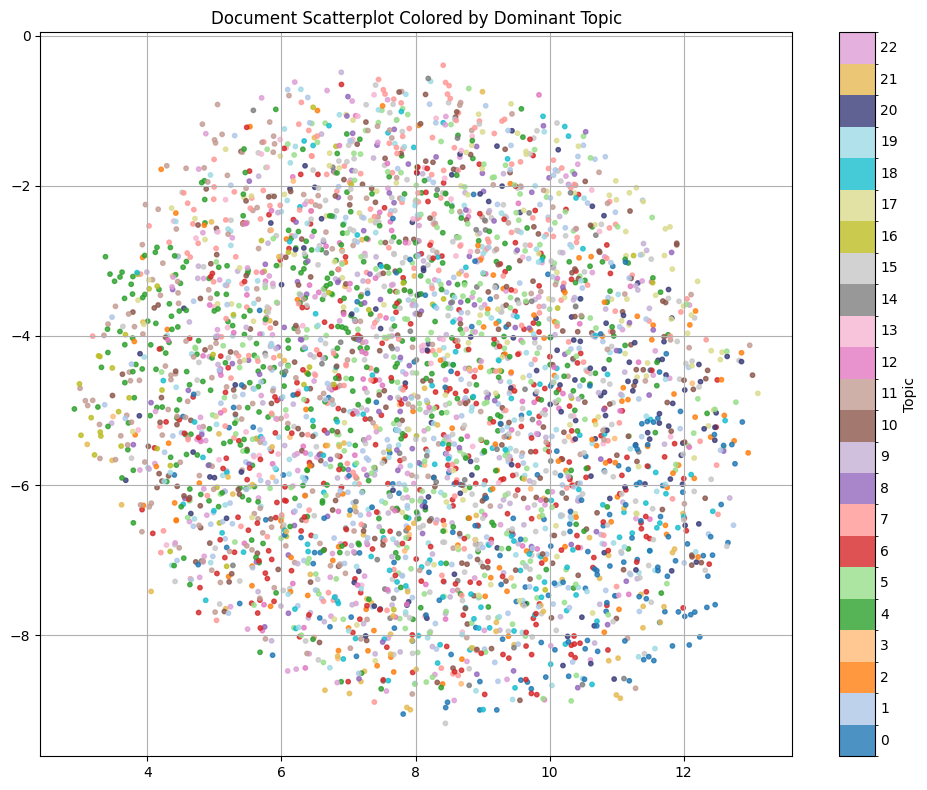

In [49]:
colors = plt.cm.tab20(np.linspace(0, 1, 20)).tolist()
colors += plt.cm.tab20b(np.linspace(0, 1, 3)).tolist()
cmap = ListedColormap(colors)


n_topics = 23
boundaries = np.arange(n_topics + 1) - 0.5

# let a BoundaryNorm map topic integers into these bins
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=topic_labels,
    cmap=cmap,
    norm=norm,
    s=10,
    alpha=0.8
)

cbar = plt.colorbar(
    scatter,
    boundaries=boundaries,
    ticks=np.arange(n_topics),
    spacing="proportional"     
)
cbar.set_label("Topic")

cbar.ax.tick_params(axis="y", length=0)  
for lbl in cbar.ax.get_yticklabels():
    lbl.set_va("center")   

plt.title("Document Scatterplot Colored by Dominant Topic")
plt.grid(True)
plt.tight_layout()
plt.show()

## <b> B - BERTEmbeddings

In [50]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [51]:
def chunk_and_embed(doc, model, max_words=100):
    words = doc.split()
    chunks = [" ".join(words[i:i+max_words]) for i in range(0, len(words), max_words)]
    chunk_embeddings = model.encode(chunks)
    return chunk_embeddings.mean(axis=0)

In [52]:
docs = topic_df['content'].tolist()

lens = [len(d.split()) for d in docs]
# document lenghts range from 50-ish words to 42k words --> embed batches and average out embeddings

In [53]:
docs = topic_df['content'].tolist()
embeddings = [chunk_and_embed(doc, model) for doc in docs]

In [62]:
n_neighbors = [5, 10, 15, 30]
min_dist = [0.01, 0.05, 0.1, 0.3]
set_op_mix_ratio = [0.2, 0.5, 0.8]

param_grid = list(itertools.product(n_neighbors, min_dist, set_op_mix_ratio))

In [ ]:
param_eval_2d = {}
for (n,d,m) in param_grid:

    X_umap = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=d,
        metric='cosine',
        set_op_mix_ratio=m,
        random_state=42
    ).fit_transform(embeddings)

    kmeans = KMeans(n_clusters=22, random_state=42)
    pred_labels = kmeans.fit_predict(X_umap)

    # Metrics
    dbi = davies_bouldin_score(X_umap, topic_labels)
    ari = adjusted_rand_score(topic_labels, pred_labels)
    nmi = normalized_mutual_info_score(topic_labels, pred_labels)

    param_eval_2d[(n,d,m)] = {
        'dbi':dbi,
        'ari':ari,
        'nmi':nmi
    }

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
df_2d = pd.DataFrame.from_dict(param_eval_2d, orient='index')

In [63]:
param_eval = {}
for (n,d,m) in param_grid:

    X_umap = umap.UMAP(
        n_components=3,
        n_neighbors=n,
        min_dist=d,
        metric='cosine',
        set_op_mix_ratio=m,
        random_state=42
    ).fit_transform(embeddings)

    kmeans = KMeans(n_clusters=22, random_state=42)
    pred_labels = kmeans.fit_predict(X_umap)

    # Metrics
    dbi = davies_bouldin_score(X_umap, topic_labels)
    ari = adjusted_rand_score(topic_labels, pred_labels)
    nmi = normalized_mutual_info_score(topic_labels, pred_labels)

    param_eval[(n,d,m)] = {
        'dbi':dbi,
        'ari':ari,
        'nmi':nmi
    }

In [64]:
df_3d = pd.DataFrame.from_dict(param_eval, orient='index')

In [ ]:
df_3d

In [65]:
X_umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    set_op_mix_ratio=0.8,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

In [66]:
X_umap = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    set_op_mix_ratio=0.2,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

In [67]:
topic_labels = topic_df['topic'].to_numpy()

# Clustering BERT+UMAP positions
kmeans = KMeans(n_clusters=22, random_state=42)
pred_labels = kmeans.fit_predict(X_umap_3d)

# Metrics
dbi = davies_bouldin_score(X_umap_3d, topic_labels)
ari = adjusted_rand_score(topic_labels, pred_labels)
nmi = normalized_mutual_info_score(topic_labels, pred_labels)

print("Davies-Bouldin Index:", dbi)
print("ARI:", ari)
print("NMI:", nmi)

Davies-Bouldin Index: 4.553781321301001
ARI: 0.26093403911839275
NMI: 0.41422055944832015


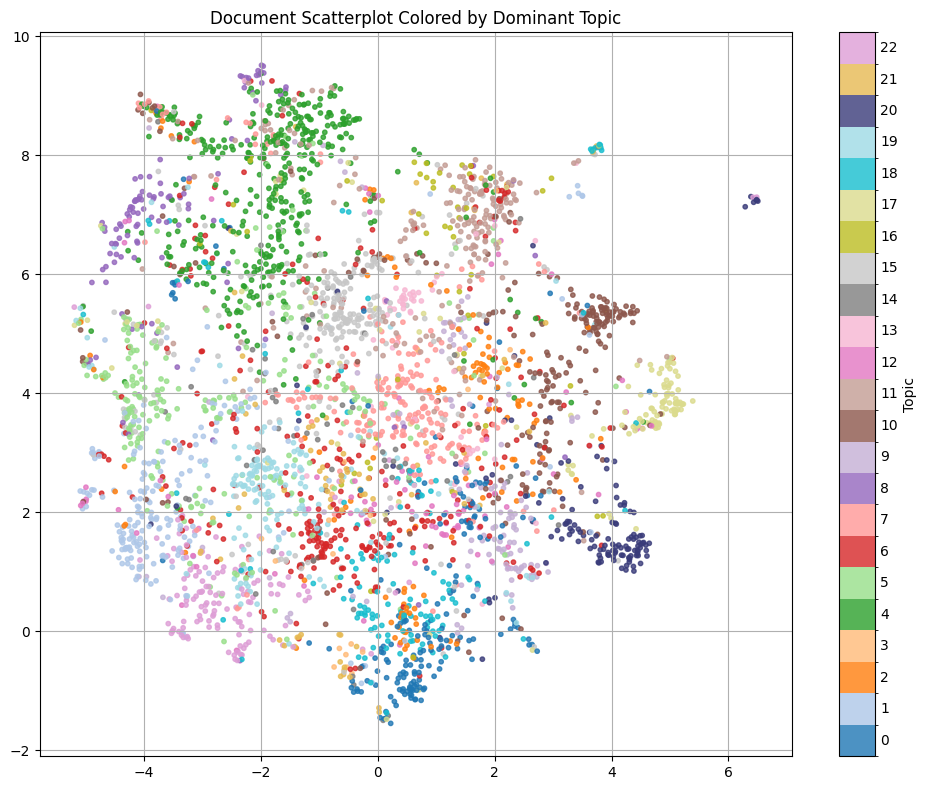

In [68]:
colors = plt.cm.tab20(np.linspace(0, 1, 20)).tolist()
colors += plt.cm.tab20b(np.linspace(0, 1, 3)).tolist()
cmap = ListedColormap(colors)

n_topics = 23
boundaries = np.arange(n_topics + 1) - 0.5

# let a BoundaryNorm map topic integers into these bins
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=topic_labels,
    cmap=cmap,
    norm=norm,
    s=10,
    alpha=0.8
)

cbar = plt.colorbar(
    scatter,
    boundaries=boundaries,
    ticks=np.arange(n_topics),
    spacing="proportional"     
)
cbar.set_label("Topic")

cbar.ax.tick_params(axis="y", length=0)  
for lbl in cbar.ax.get_yticklabels():
    lbl.set_va("center")   

plt.title("Document Scatterplot Colored by Dominant Topic")
plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
fig = px.scatter_3d(
    x=X_umap_3d[:, 0],
    y=X_umap_3d[:, 1],
    z=X_umap_3d[:, 2],
    color=[str(label) for label in topic_labels],
    color_discrete_sequence=px.colors.qualitative.Dark24,  # up to 24 distinct colors
    title="3D UMAP of BERT Embeddings by Topic"
)

fig.update_traces(marker=dict(size=3, opacity=0.8))

fig.update_layout(
    dragmode="zoom",
    scene=dict(
        camera=dict(
            eye=dict(x=0.6, y=0.6, z=0.6)  # default is 1.25ish on each axis
        )
    )
)

fig.write_html("umap3d.html", auto_open=True)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
